In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

df = pd.read_excel('data.xlsx', sheet_name='Data_ML')

In [20]:
df = df.drop(columns='Unnamed: 0')
df.head()

,Year,GDP Growth (%) — TARGET,Lag GDP Growth t-1 (%),Inflation CPI t-1 (%),Unemployment t-1 (%),Gov. Expenditure t-1 (% GDP),Tax Revenue t-1 (% GDP),Trade Openness t-1 (% GDP),FDI Inflows t-1 (% GDP),WGI Gov. Eff. t-1,Econ. Freedom t-1
0,2001,4.7253,5.8000,168.6202,12.193,19.4785,16.6247,141.6092,0.9327,-1.3091,41.3
1,2002,5.0453,4.7253,61.1349,11.561,21.5528,15.7547,137.0449,0.7754,-1.3614,38.0
2,2003,7.0432,5.0453,42.5375,10.874,21.0293,14.2010,131.0021,1.6931,-1.4137,39.0
3,2004,11.4497,7.0432,28.3978,10.191,21.3793,17.6881,134.1419,0.9638,-1.4203,39.7
4,2005,9.4000,11.4497,18.1082,9.463,20.6032,18.3713,142.1365,0.7078,-1.2600,43.1


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          24 non-null     int64  
 1   GDP Growth (%) — TARGET       24 non-null     float64
 2   Lag GDP Growth t-1 (%)        24 non-null     float64
 3   Inflation CPI t-1 (%)         24 non-null     float64
 4   Unemployment t-1 (%)          24 non-null     float64
 5   Gov. Expenditure t-1 (% GDP)  24 non-null     float64
 6   Tax Revenue t-1 (% GDP)       24 non-null     float64
 7   Trade Openness t-1 (% GDP)    24 non-null     float64
 8   FDI Inflows t-1 (% GDP)       24 non-null     float64
 9   WGI Gov. Eff. t-1             24 non-null     float64
 10  Econ. Freedom t-1             24 non-null     float64
dtypes: float64(10), int64(1)
memory usage: 2.2 KB


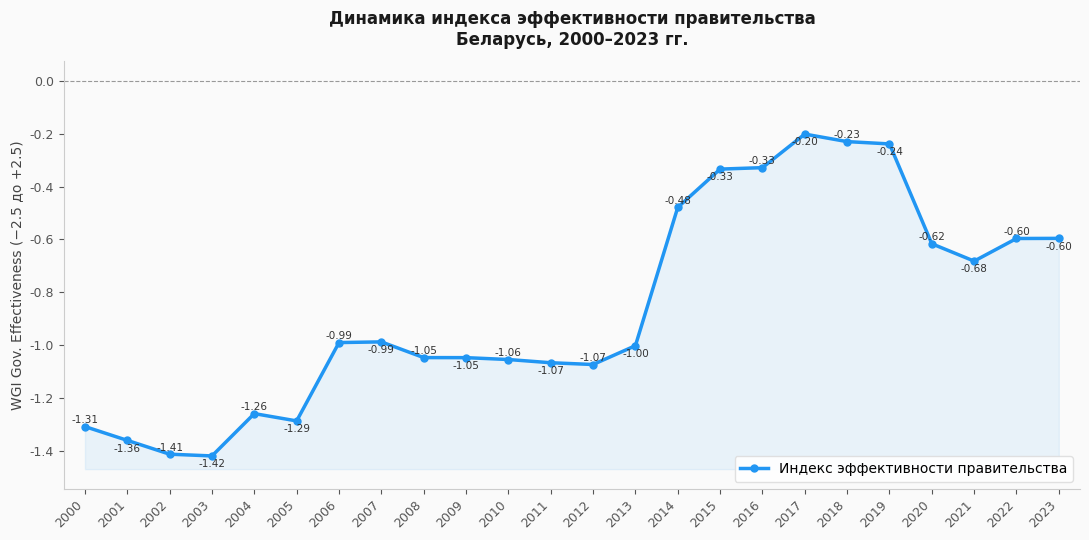

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── загрузка данных ──
df = pd.read_excel('data.xlsx', sheet_name='Data_Full')
df = df.rename(columns={
    'Year': 'year',
    'WGI Gov. Effectiveness': 'wgi',
})
df = df[pd.to_numeric(df['year'], errors='coerce').notna()].copy()
df['year'] = df['year'].astype(int)
df['wgi']  = pd.to_numeric(df['wgi'], errors='coerce')
df = df.sort_values('year').dropna(subset=['wgi']).reset_index(drop=True)

years = df['year'].values
wgi   = df['wgi'].values

# ── стиль ──
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

# ── заливка под линией ──
ax.fill_between(years, wgi, wgi.min() - 0.05,
                alpha=0.08, color='#2196F3', interpolate=True)

# ── линия ──
ax.plot(years, wgi, color='#2196F3', lw=2.5,
        marker='o', ms=5, zorder=3,
        label='Индекс эффективности правительства')

# ── подписи значений (через одну точку, чтобы не перекрывались) ──
for i, (yr, val) in enumerate(zip(years, wgi)):
    offset = 0.03 if i % 2 == 0 else -0.06
    ax.annotate(f'{val:.2f}',
                xy=(yr, val),
                xytext=(0, offset * 40),
                textcoords='offset points',
                ha='center', va='bottom' if offset > 0 else 'top',
                fontsize=7.5, color='#333333')

# ── нулевая линия ──
ax.axhline(0, color='#999999', lw=0.8, ls='--', zorder=1)

# ── оформление осей ──
ax.set_xlim(years[0] - 0.5, years[-1] + 0.5)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('WGI Gov. Effectiveness (−2.5 до +2.5)',
              fontsize=10, color='#444444')
ax.tick_params(axis='y', labelsize=9, colors='#555555')
ax.tick_params(axis='x', colors='#555555')
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

# ── легенда ──
ax.legend(fontsize=10, frameon=True, framealpha=0.9,
          loc='lower right', edgecolor='#dddddd')

# ── заголовок ──
ax.set_title('Динамика индекса эффективности правительства\n'
             'Беларусь, 2000–2023 гг.',
             fontsize=12, fontweight='bold', color='#1a1a1a', pad=12)

plt.tight_layout()
plt.savefig('wgi_dynamics.png', dpi=300, bbox_inches='tight', facecolor='#fafafa')
plt.show()

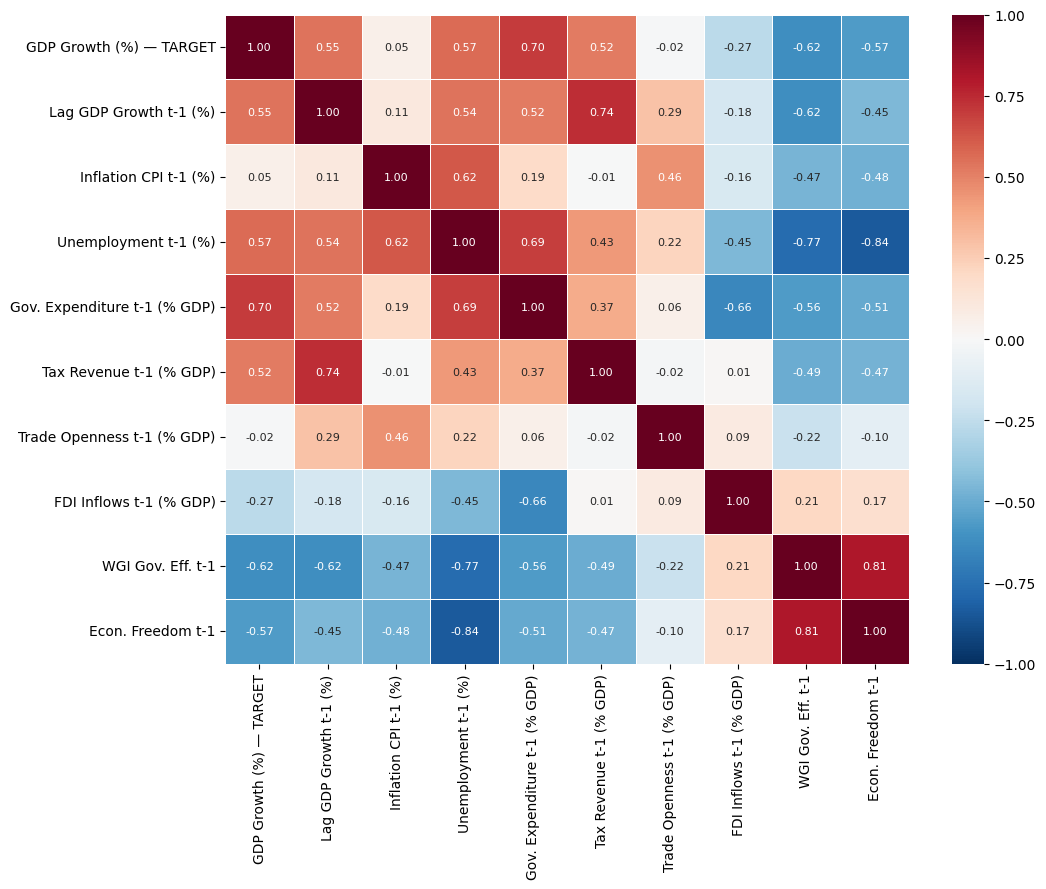

<Figure size 640x480 with 0 Axes>

In [29]:
import seaborn as sns
corr = df.drop(columns=['Year']).corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.tight_layout()
plt.show()
plt.savefig('corr.png')

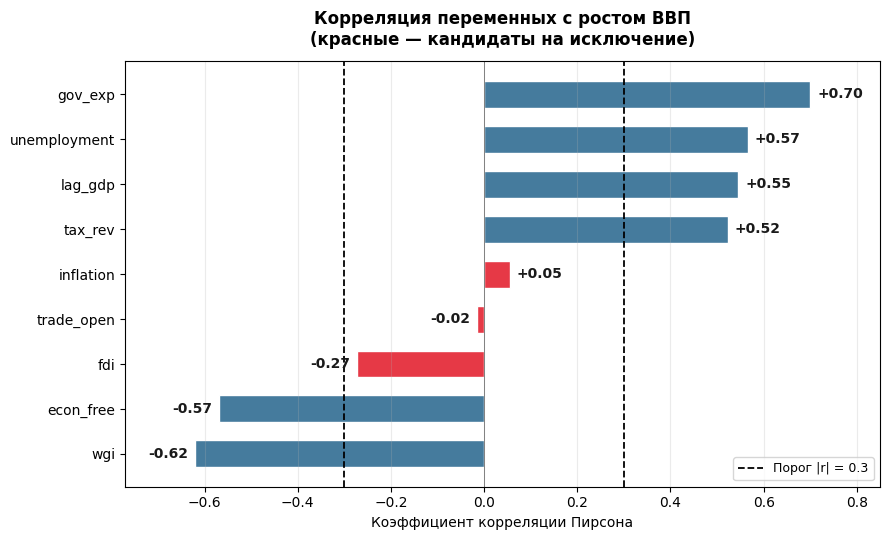

In [ ]:
# ── загрузка данных ──
df = pd.read_excel('data.xlsx', sheet_name='Data_ML')
df = df.rename(columns={
    'Year': 'year',
    'GDP Growth (%) — TARGET': 'gdp_growth',
    'Lag GDP Growth t-1 (%)': 'lag_gdp',
    'Inflation CPI t-1 (%)': 'inflation',
    'Unemployment t-1 (%)': 'unemployment',
    'Gov. Expenditure t-1 (% GDP)': 'gov_exp',
    'Tax Revenue t-1 (% GDP)': 'tax_rev',
    'Trade Openness t-1 (% GDP)': 'trade_open',
    'FDI Inflows t-1 (% GDP)': 'fdi',
    'WGI Gov. Eff. t-1': 'wgi',
    'Econ. Freedom t-1': 'econ_free',
})
df = df[pd.to_numeric(df['year'], errors='coerce').notna()].copy()
for c in df.columns[1:]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# ── корреляция с целевой переменной ──
cols = ['lag_gdp','inflation','unemployment','gov_exp','tax_rev',
        'trade_open','fdi','wgi','econ_free']

corr = df[['gdp_growth'] + cols].corr()['gdp_growth'].drop('gdp_growth')
corr = corr.sort_values()

THRESHOLD = 0.3
colors = ['#e63946' if abs(v) < THRESHOLD else '#457b9d' for v in corr]

# ── график ──
fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(corr.index, corr.values, color=colors,
               edgecolor='white', height=0.6)

# подписи значений
for bar, val in zip(bars, corr.values):
    offset = 0.015 if val >= 0 else -0.015
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset,
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}',
            va='center', ha=ha,
            fontsize=10, fontweight='bold',
            color='#1a1a1a')

# пороговые линии
ax.axvline( THRESHOLD, color='black', ls='--', lw=1.3,
            label=f'Порог |r| = {THRESHOLD}')
ax.axvline(-THRESHOLD, color='black', ls='--', lw=1.3)
ax.axvline(0, color='gray', lw=0.7)

ax.set_title('Корреляция переменных с ростом ВВП\n'
             '(красные — кандидаты на исключение)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Коэффициент корреляции Пирсона', fontsize=10)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.25)
ax.set_xlim(corr.min() - 0.15, corr.max() + 0.15)

plt.tight_layout()
plt.savefig('corr_target.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

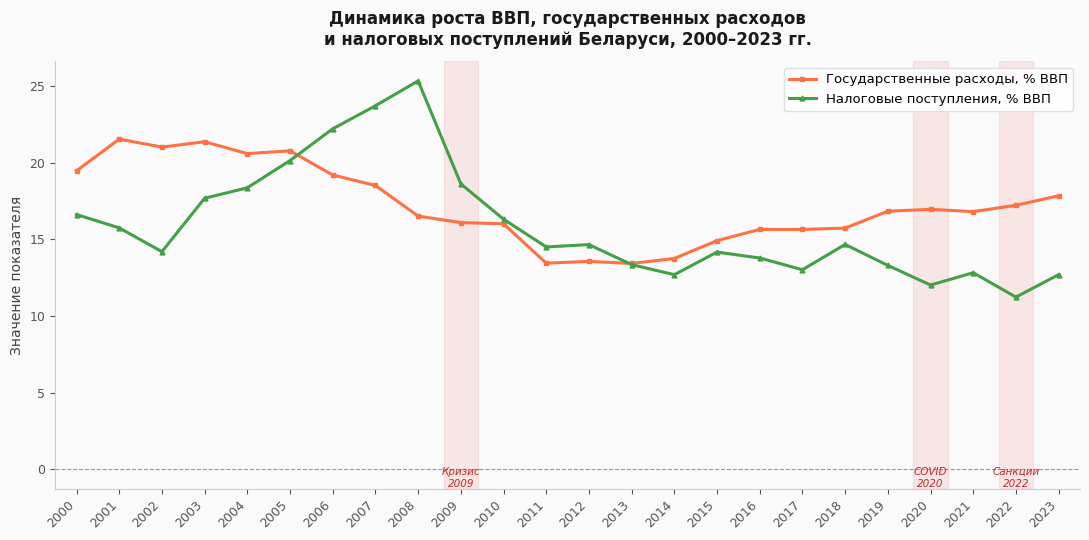

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── загрузка данных ──
df = pd.read_excel('data.xlsx', sheet_name='Data_Full')
df = df.rename(columns={
    'Year': 'year',
    'GDP Growth (%)': 'gdp_growth',
    'Gov. Expenditure (% GDP)': 'gov_exp',
    'Tax Revenue (% GDP)': 'tax_rev',
})
df = df[pd.to_numeric(df['year'], errors='coerce').notna()].copy()
for c in ['year', 'gdp_growth', 'gov_exp', 'tax_rev']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.sort_values('year').reset_index(drop=True)

years = df['year'].values

# ── стиль ──
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

# ── линии ──
ax.plot(years, df['gov_exp'],    color='#FF7043', lw=2.2,
        marker='s', ms=3.5, zorder=3,
        label='Государственные расходы, % ВВП')
ax.plot(years, df['tax_rev'],    color='#43A047', lw=2.2,
        marker='^', ms=3.5, zorder=3,
        label='Налоговые поступления, % ВВП')

# ── нулевая линия ──
ax.axhline(0, color='#999999', lw=0.8, ls='--', zorder=1)

# ── кризисные годы — вертикальные полосы ──
for yr, label in [(2009, 'Кризис\n2009'), (2020, 'COVID\n2020'), (2022, 'Санкции\n2022')]:
    ax.axvspan(yr - 0.4, yr + 0.4, alpha=0.10, color='#e53935', zorder=0)
    ax.text(yr, ax.get_ylim()[0] if ax.get_ylim()[0] > -8 else -7.5,
            label, ha='center', va='bottom', fontsize=7.5,
            color='#c62828', style='italic')

# ── оформление осей ──
ax.set_xlim(years[0] - 0.5, years[-1] + 0.5)
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))
ax.set_ylabel('Значение показателя', fontsize=10, color='#444444')
ax.tick_params(axis='y', labelsize=9, colors='#555555')
ax.tick_params(axis='x', colors='#555555')
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# ── легенда ──
ax.legend(fontsize=9.5, frameon=True, framealpha=0.9,
          loc='upper right', edgecolor='#dddddd')

# ── заголовок и подпись ──
ax.set_title('Динамика роста ВВП, государственных расходов\n'
             'и налоговых поступлений Беларуси, 2000–2023 гг.',
             fontsize=12, fontweight='bold', color='#1a1a1a', pad=12)

plt.tight_layout()
plt.savefig('dynamics.png', dpi=300, bbox_inches='tight', facecolor='#fafafa')
plt.show()